In [20]:
from datetime import date
from operator import truth, concat
from os import PRIO_DARWIN_NONUI

import yfinance as yf
import pandas as pd
import numpy as np
from statistics import variance
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.tools import add_constant
from sympy import false, true
import statsmodels.api as sm
from sympy.physics.control.control_plots import plt
import requests
from sympy.physics.vector.printing import params

In [21]:
ticker = "COIN"
benchmark = "BTC-USD"
benchmark2 = "SPY"

In [22]:
def data(t, b):
    stock = yf.download(t, start="2021-04-14",auto_adjust=False)["Adj Close"]
    market = yf.download(b, start="2021-04-14",auto_adjust=False)["Adj Close"]
    stock_returns = stock.pct_change()
    market_returns = market.pct_change()
    returns = pd.concat([stock_returns, market_returns], axis=1,sort=False).dropna()
    return returns

In [23]:
def stat(t, b):
    returns = data(t, b)
    covariance = returns.cov().loc[t,b]
    variance = returns[b].var()
    beta = covariance / variance
    X = returns[b]
    Y = returns[t]
    plt.figure()


    plt.scatter(X,Y, color = 'blue')
    slope, intercept, rvalue, pvalue, stdv = stats.linregress(X, Y)
    plt.plot(X, slope * X + intercept, color = 'red')
    print(round(beta,10) == round(slope,10))
    print("R-squared:", format(round(rvalue**2,3),"%"))
    print("Slope:", round(slope,3))
    plt.title(t + "-" + b)
    plt.xlabel(b + " Returns")
    plt.ylabel(t + " Returns")


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


True
R-squared: 30.400000%
Slope: 0.91


[*********************100%***********************]  1 of 1 completed

True
R-squared: 27.700000%
Slope: 2.656


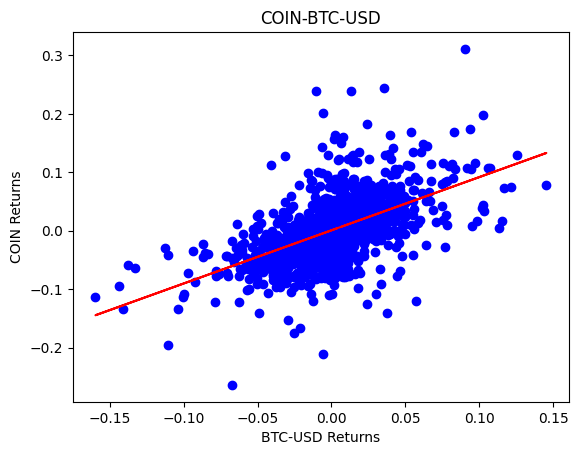

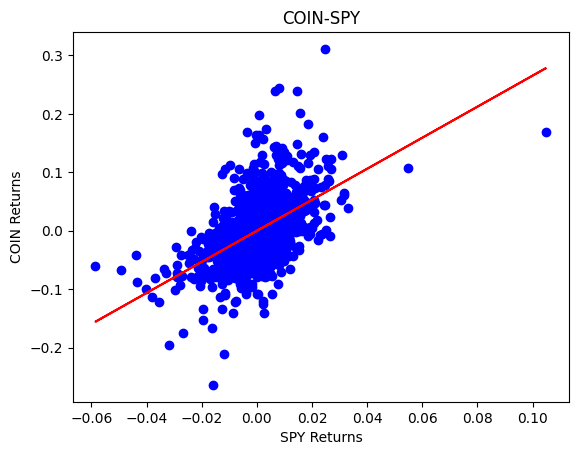

In [24]:
stat(ticker,benchmark)
stat(ticker,benchmark2)

In [25]:
def multivariate(t, b, b2):
    returns = data(t,b)
    returns2 = data(t,b2)
    return_rolling = returns[b].rolling(30).std().dropna()
    alldata = pd.concat([returns, returns2[b2],return_rolling], axis=1).dropna()

    alldata.columns = [t, b, b2, b + '_vol']

    Y = alldata[t]
    X = alldata[[b,b2,b + '_vol']]

    X = sm.add_constant(X)

    multi_reg = sm.OLS(Y, X).fit()

    print(multi_reg.summary())


In [26]:
multivariate(ticker,benchmark,benchmark2)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

                            OLS Regression Results                            
Dep. Variable:                   COIN   R-squared:                       0.433
Model:                            OLS   Adj. R-squared:                  0.431
Method:                 Least Squares   F-statistic:                     305.1
Date:                Sun, 15 Mar 2026   Prob (F-statistic):          3.23e-147
Time:                        17:09:54   Log-Likelihood:                 2138.6
No. Observations:                1205   AIC:                            -4269.
Df Residuals:                    1201   BIC:                            -4249.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -0.0003      0.004     -0.073      

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


<Axes: xlabel='Date'>

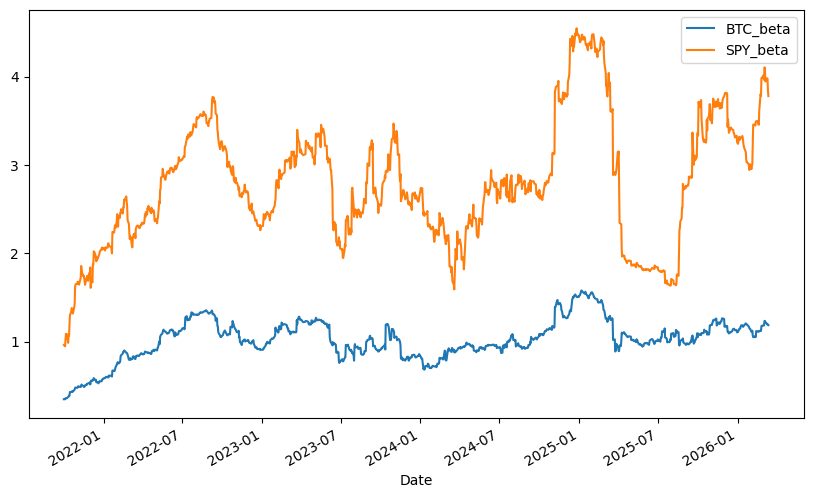

In [27]:
returns = data(ticker,benchmark)
returns2 = data(ticker,benchmark2)
btc_vol = returns[benchmark].rolling(30).std()
alldata = pd.concat([returns, returns2[benchmark2], btc_vol], axis=1).dropna()
alldata.columns = [ticker
                ,   benchmark
                ,   benchmark2
                ,   benchmark + '_vol']

window = 90

coin = alldata[ticker]
btc = alldata[benchmark]
spy = alldata[benchmark2]

beta_btc = coin.rolling(window).cov(btc) / btc.rolling(window).var()
beta_spy = coin.rolling(window).cov(spy) / spy.rolling(window).var()

rolling_betas = pd.concat([beta_btc, beta_spy], axis=1)
rolling_betas.columns = ["BTC_beta", "SPY_beta"]
rolling_betas.plot(figsize=(10,6))


In [43]:

def comp(ticker_group):
    cols = []
    for ticker in ticker_group:
        t = yf.Ticker(ticker)
        try:
            info = {"Ticker": ticker,
                "market_cap": t.info.get('marketCap',0),
                "ev": t.info.get("enterpriseValue",0),
                "revenue": t.info.get("totalRevenue",0),
                "gross_margins": t.info.get("grossMargins",0),
                "ebitda": t.info.get("ebitda",0),
                "ev/rev": t.info.get("enterpriseToRevenue",0),
                "ev/ebitda": t.info.get("enterpriseToEbitda",0),
                "trailing_pe": t.info.get("trailingPE",0),
                "earnings_growth": t.info.get("earningsGrowth",0),
                "revenue_growth": t.info.get("revenueGrowth",0)}
            cols.append(info)
        except:
            print("Missing data for " + ticker)
    df=pd.DataFrame(cols)

    if df.empty:
        return df

    for col in ["market_cap", "ev", "revenue", "ebitda"]:
        if col in df.columns:
            df[col] = df[col] / 1e9

    if "gross_margins" in df.columns and "revenue" in df.columns:
        df["gross_margins"] = df["gross_margins"] * df["revenue"]
    if "ev/ebitda" in df.columns:
        df.sort_values("ev/ebitda", ascending=False, inplace=True)

    ev_gm = df["ev"]/df["gross_margins"]
    df["ev/gm"] = ev_gm

    df = df.loc[:,['Ticker', 'market_cap', 'ev', 'revenue', 'gross_margins', 'ebitda',
       'ev/rev', 'ev/ebitda', 'ev/gm', 'trailing_pe', 'earnings_growth',
       'revenue_growth']]
    df.replace(0, np.nan, inplace=True)

    return df

In [46]:
tickers_coinbase_core = [
    "COIN",
    "HOOD",
    "IBKR",
    "CME",
    "NDAQ"
]

tickers_coinbase_payments = [
    "PYPL",
    "V",
    "MA",
    "CRCL"
]

comp(tickers_coinbase_core)

,Ticker,market_cap,ev,revenue,gross_margins,ebitda,ev/rev,ev/ebitda,ev/gm,trailing_pe,earnings_growth,revenue_growth
0,COIN,52.726149,47.897391,6.883438,5.863175,1.671161,6.958,28.661,8.169190,43.840805,NaN,-0.222
3,CME,111.952167,110.891270,6.506800,6.506800,4.590000,17.042,24.159,17.042366,27.928251,0.350,0.080
4,NDAQ,48.837239,57.536004,5.249000,5.249000,3.117000,10.961,18.459,10.961327,27.679611,0.476,0.134
1,HOOD,66.073633,65.887633,4.473000,4.131978,NaN,14.730,NaN,15.945784,35.800000,-0.345,0.265
2,IBKR,112.523887,-35.458335,6.209000,5.745995,NaN,-5.711,NaN,-6.170965,29.815315,0.303,0.152


In [47]:
comp(tickers_coinbase_payments)

,Ticker,market_cap,ev,revenue,gross_margins,ebitda,ev/rev,ev/ebitda,ev/gm,trailing_pe,earnings_growth,revenue_growth
2,MA,444.425044,453.057610,32.790999,32.790999,20.544000,13.817,22.053,13.816524,30.126434,0.242,0.176
1,V,592.178119,590.821917,41.391002,40.470881,28.987001,14.274,20.382,14.598692,28.812384,0.174,0.146
0,PYPL,42.010776,43.211837,33.172001,13.761073,6.649000,1.303,6.499,3.140150,8.299446,0.394,0.037
3,CRCL,30.631152,26.463107,2.746642,0.238106,-0.086789,9.635,-304.913,111.139853,NaN,8.802,0.769
